In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/howonmjeong/anomalies/answer_anomalies.csv
/kaggle/input/datasets/howonmjeong/anomalies/health_survey.csv


In [2]:
path='/kaggle/input/datasets/howonmjeong/anomalies/'
df = pd.read_csv(path+'health_survey.csv')
answers = pd.read_csv(path+'answer_anomalies.csv')

In [3]:
df.head()

,soldier_id,bmi,sleep_hours,exercise_freq,smoke,alcohol
0,S001,23.1,6.7,3,0,1
1,S002,26.1,5.7,3,0,1
2,S003,25.8,5.7,3,0,0
3,S004,21.8,5.8,6,0,0
4,S005,22.3,6.8,2,0,0


In [4]:
print(df.isnull().sum(),df.describe())

soldier_id       0
bmi              0
sleep_hours      0
exercise_freq    0
smoke            0
alcohol          0
dtype: int64               bmi  sleep_hours  exercise_freq       smoke     alcohol
count  500.000000   500.000000     500.000000  500.000000  500.000000
mean    23.226000     6.451400       3.568000    0.266000    0.418000
std      2.892621     1.125002       1.822091    0.442307    0.493724
min     14.200000     2.100000       0.000000    0.000000    0.000000
25%     21.600000     5.800000       2.000000    0.000000    0.000000
50%     23.200000     6.500000       4.000000    0.000000    0.000000
75%     24.525000     7.100000       5.000000    1.000000    1.000000
max     39.300000    11.900000       7.000000    1.000000    1.000000


In [5]:
X_train = df.drop(columns = 'soldier_id')

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

In [6]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05, random_state=42)
df['anomaly'] = iso.fit_predict(X_train)

In [7]:
print(df['anomaly'].value_counts(normalize='True')[-1])

0.05


(500, 2)


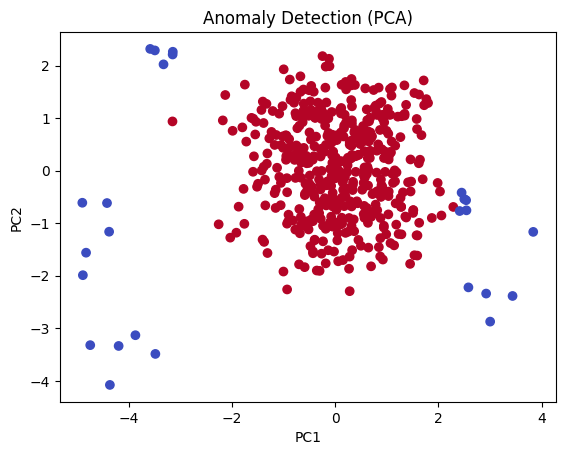

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_train)
print(pca_result.shape)

import matplotlib.pyplot as plt

plt.scatter(pca_result[:, 0], pca_result[:, 1], c=df['anomaly'], cmap='coolwarm')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Anomaly Detection (PCA)')
plt.show()

In [9]:
df_anomalies = df[df['anomaly']==-1]
answers['soldier_id'].isin(df_anomalies['soldier_id']).value_counts()

soldier_id
True    25
Name: count, dtype: int64

정답은 다 맞지만 PCA 상 눈에 띄는..